In [37]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open('Oracle-scripts/prices.pickle', mode='rb') as fp:
    data = pickle.load(fp, encoding='utf-8')

In [3]:
type(data)

collections.defaultdict

In [29]:
keys = data.keys()

In [31]:
len(keys), type(keys)

(4, dict_keys)

In [32]:
for x in keys:
    print(x)

0
5
10
15


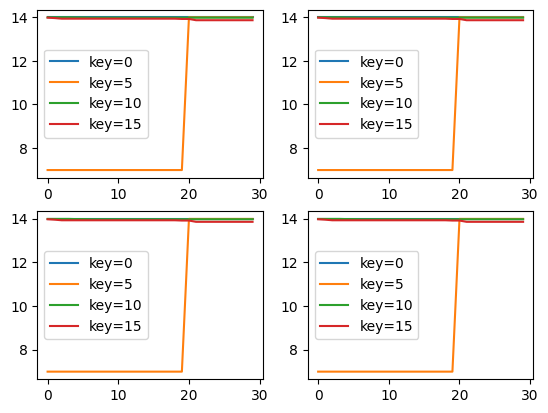

In [56]:
fig, axs = plt.subplots(nrows=2,ncols=2)
assert axs.shape == (2,2)
for row in range(2):
    for col in range(2):
        axs[row,col].plot(list(map(lambda x: x[0], data[key])), label=f'{key=}')
        axs[row,col].legend()
plt.show()

In [13]:
len(data[0]), len(data[0][0])

(30, 7)

In [58]:
data_0 = np.asarray(data[0])
data_5 = np.asarray(data[5])
data_10 = np.asarray(data[10])
data_15 = np.asarray(data[15])

assert data_0.shape == (30,7)
assert data_5.shape == (30,7)
assert data_10.shape == (30,7)
assert data_15.shape == (30,7)
assert data_0.ndim == 2
data_0.dtype, data_0.shape

In [57]:
import tabulate

Need the following data:

- Mean
- Min
- Max
- Median
- zeros

In [82]:
symbols = ["ATOM", "OSMO", "USDC", "WETH", "DAI", "CMDX", "CMST"]

In [89]:
def stats(array):
    assert array.ndim == 2
    total = array.shape[0]
    mean = np.mean(array, axis=0)
    median = np.median(array, axis=0)
    mini = np.min(array, axis=0)
    maxi = np.max(array, axis=0)
    zeros = np.count_nonzero(array, axis=0)
    return np.vstack((symbols,mean,median,mini,maxi,total-zeros))

In [90]:
heads = ['mean','median','min','max','zeros']

In [91]:
result = stats(data_0)

In [92]:
result.shape

(6, 7)

# For the following results, following is the methodolgy:

- Prices are fetched from the osmosis and coingecko with a
delay between each api call.
- This was repeated times 30.
- No delay between switching from delay period to another. This resulted in skewed results for delay=5.
- Only 7 token prices were fetched: ATOM, OSMO, USDC, WETH, DAI, CMDX, CMST.
- Calculated the mean, median, minimum price, maximum price and the count of zero values in array. Zero represents price feed from none of the two sources.

## Fetching price without any delay (theoretically).

In [93]:
print(tabulate.tabulate(result.T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │   13.9891   │   13.9891   │   13.9891   │   13.9891   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.55022  │    1.55022  │    1.55022  │    1.55022  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    1.00028  │    1.00028  │    1.00028  │    1.00028  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1591.02     │ 1591.02     │ 1591.02     │ 1591.02     │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.997436 │    0.997436 │    0.997436 │    0.997436 │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.18505  │   

## Fetching price with 5 sec delay after each call.

In [94]:
print(tabulate.tabulate(stats(data_5).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │    9.32367  │   6.99097   │   6.99097   │   13.9891   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.03348  │   0.775112  │   0.775112  │    1.55022  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    0.666761 │   0.5       │   0.5       │    1.00028  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1060.3      │ 794.943     │ 794.943     │ 1591.02     │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.664574 │   0.498144  │   0.498144  │    0.997436 │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.123343 │   

## Fetching price with 10 sec delay after each call.

In [95]:
print(tabulate.tabulate(stats(data_10).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │   13.9763   │   13.9738   │   13.9738   │   13.9891   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.54934  │    1.54921  │    1.54921  │    1.55022  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    1.00022  │    1.0002   │    1.0002   │    1.00028  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1590.82     │ 1590.86     │ 1589.96     │ 1591.02     │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.997086 │    0.997038 │    0.996966 │    0.997436 │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.184946 │   

## Fetching price with 15 sec delay after each call.

In [96]:
print(tabulate.tabulate(stats(data_15).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │   13.9072   │   13.9269   │   13.8559   │   13.9738   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.54434  │    1.54606  │    1.54011  │    1.54921  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    1.0001   │    1.0007   │    0.998825 │    1.0007   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1585.18     │ 1587.19     │ 1580.37     │ 1590.86     │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.997695 │    0.998217 │    0.996578 │    0.998317 │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.184428 │   

In [107]:
with open('Oracle-scripts/prices1.pickle', mode='rb') as fp:
    data = pickle.load(fp, encoding='utf-8')

In [109]:
data_0 = np.asarray(data[0])
data_5 = np.asarray(data[5])
data_10 = np.asarray(data[10])
data_15 = np.asarray(data[15])
data_20 = np.asarray(data[20])

assert data_0.shape == (60,7)
assert data_5.shape == (60,7)
assert data_10.shape == (60,7)
assert data_15.shape == (60,7)
assert data_20.shape == (60,7)
assert data_0.ndim == 2
data_0.dtype, data_0.shape

(dtype('float64'), (60, 7))

# For the following results, methodolgy used:

- Prices are fetched from the osmosis and coingecko with a delay between each api call.
- This was repeated times 30.
- 30 sec delay when switching from one delay period to another.
- Only 7 token prices were fetched: ATOM, OSMO, USDC, WETH, DAI, CMDX, CMST.
- Calculated the mean, median, minimum price, maximum price and the count of zero values in array. Zero represents price feed from none of the two sources.

## Fetching price with 0 sec delay after each call.

In [110]:
print(tabulate.tabulate(stats(data_0).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬────────────┬─────────────┬─────────┐
│      │        mean │      median │        min │         max │   zeros │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ ATOM │   10.2112   │   10.2112   │   6.81327  │   13.6092   │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ OSMO │    1.1259   │    1.1259   │   0.750683 │    1.50112  │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ USDC │    0.749968 │    0.749968 │   0.5      │    0.999936 │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ WETH │ 1164.99     │ 1164.99     │ 775.951    │ 1554.02     │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ DAI  │    0.749232 │    0.749232 │   0.499237 │    0.999228 │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ CMDX │    0.117483 │    0.117483 │  

## Fetching price with 5 sec delay after each call.

In [111]:
print(tabulate.tabulate(stats(data_5).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬────────────┬─────────────┬─────────┐
│      │        mean │      median │        min │         max │   zeros │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ ATOM │   12.3452   │   13.5802   │   6.81327  │   13.6092   │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ OSMO │    1.36165  │    1.49761  │   0.750683 │    1.50112  │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ USDC │    0.908248 │    0.999848 │   0.5      │    0.999936 │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ WETH │ 1410.09     │ 1551.48     │ 775.951    │ 1554.02     │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ DAI  │    0.907614 │    0.999242 │   0.499237 │    0.999349 │       0 │
├──────┼─────────────┼─────────────┼────────────┼─────────────┼─────────┤
│ CMDX │    0.142268 │    0.155901 │  

## Fetching price with 10 sec delay after each call.

In [112]:
print(tabulate.tabulate(stats(data_10).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │   13.5955   │   13.5944   │   13.5826   │   13.6033   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.49932  │    1.49945  │    1.49788  │    1.5002   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    0.99998  │    0.999858 │    0.999741 │    1.00021  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1554.11     │ 1553.64     │ 1552.01     │ 1555.55     │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.999635 │    0.999685 │    0.999399 │    0.999832 │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.157416 │   

## Fetching price with 15 sec delay after each call.

In [113]:
print(tabulate.tabulate(stats(data_15).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │   13.5804   │   13.5832   │   13.5722   │   13.5927   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.49986  │    1.49991  │    1.49964  │    1.50006  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    1.00008  │    1.00021  │    0.999741 │    1.00028  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1553.06     │ 1553.35     │ 1551.65     │ 1554.27     │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.999654 │    0.999615 │    0.999554 │    0.99981  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.157458 │   

## Fetching price with 20 sec delay after each call.

In [114]:
print(tabulate.tabulate(stats(data_20).T, headers=heads, tablefmt='simple_grid'))

┌──────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┐
│      │        mean │      median │         min │         max │   zeros │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ ATOM │   13.5519   │   13.5486   │   13.5446   │   13.5629   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ OSMO │    1.49531  │    1.49526  │    1.49444  │    1.4963   │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ USDC │    1.0005   │    1.00049  │    1.0004   │    1.00063  │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ WETH │ 1552.85     │ 1553.06     │ 1551.86     │ 1553.5      │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ DAI  │    0.999532 │    0.999451 │    0.99912  │    0.999926 │       0 │
├──────┼─────────────┼─────────────┼─────────────┼─────────────┼─────────┤
│ CMDX │    0.156865 │   